In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [33]:
df = pd.read_csv("India-Tourism-Statistics-2021-monuments.csv")
df.head()

,Circle,Name of the Monument,Domestic-2019-20,Foreign-2019-20,Domestic-2020-21,Foreign-2020-21,% Growth 2021-21/2019-20-Domestic,% Growth 2021-21/2019-20-Foreign
0,Agra,Taj Mahal,4429710,645415,1259892,9034,-71.56,-98.60
1,Agra,Agra Fort,1627154,386522,371242,2810,-77.18,-99.27
2,Agra,Fatehpur Sikri,454376,184751,107835,574,-76.27,-99.69
3,Agra,Akbar Tomb Sikandra,229270,19625,99509,321,-56.60,-98.36
4,Agra,Mariam tomb Sikandra,22517,414,9765,31,-56.63,-92.51


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Circle                             178 non-null    object 
 1   Name of the Monument               178 non-null    object 
 2   Domestic-2019-20                   178 non-null    int64  
 3   Foreign-2019-20                    178 non-null    int64  
 4   Domestic-2020-21                   178 non-null    int64  
 5   Foreign-2020-21                    178 non-null    int64  
 6   % Growth 2021-21/2019-20-Domestic  177 non-null    float64
 7   % Growth 2021-21/2019-20-Foreign   176 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 11.3+ KB


In [6]:
df.describe()

,Domestic-2019-20,Foreign-2019-20,Domestic-2020-21,Foreign-2020-21,% Growth 2021-21/2019-20-Domestic,% Growth 2021-21/2019-20-Foreign
count,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,177.000000,176.000000
mean,7.349507e+05,4.645889e+04,2.216811e+05,7008.859551,-28.225367,937.419148
std,3.375224e+06,2.412842e+05,1.009087e+06,40252.182392,336.849629,6859.564220
min,5.300000e+02,0.000000e+00,0.000000e+00,0.000000,-99.990000,-100.000000
25%,4.586950e+04,1.697500e+02,1.427275e+04,14.500000,-76.760000,-99.010000
50%,1.765070e+05,1.747000e+03,5.747650e+04,101.500000,-64.010000,-97.000000
75%,4.641905e+05,1.242850e+04,1.524880e+05,340.000000,-50.860000,-81.625000
max,4.360708e+07,2.756561e+06,1.315308e+07,415859.000000,4233.770000,62078.430000


In [10]:
df.columns = df.columns.str.strip()

# Remove missing values
df = df.dropna()

In [9]:
df["Total_Visitors_2019_20"] = df["Domestic-2019-20"] + df["Foreign-2019-20"]
df["Total_Visitors_2020_21"] = df["Domestic-2020-21"] + df["Foreign-2020-21"]

In [11]:
df = df[~df["Name of the Monument"].isin(["Total", "Grand Total"])] #keep only monument rows 
df["Total_Visitors_2019_20"] = pd.to_numeric(df["Total_Visitors_2019_20"], errors='coerce')

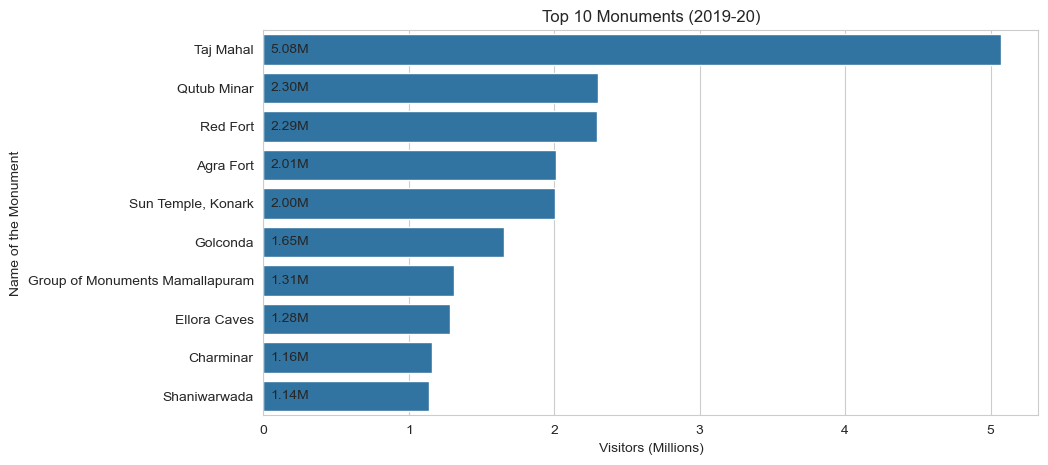

In [15]:
top10 = df.sort_values(by="Total_Visitors_2019_20", ascending=False).head(10)
# Convert to millions
top10["Visitors_M"] = top10["Total_Visitors_2019_20"] / 1_000_000


# Plot
plt.figure(figsize=(10,5))
sns.barplot(x="Visitors_M", y="Name of the Monument", data=top10, color="#1f77b4")

# Labels
plt.xlabel("Visitors (Millions)")
plt.title("Top 10 Monuments (2019-20)")

# Add values on bars
for i, v in enumerate(top10["Visitors_M"]):
    plt.text(0.05, i, f"{v:.2f}M", va='center')

plt.show()

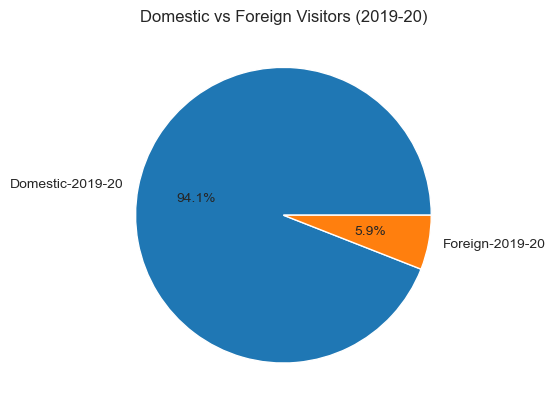

In [16]:
df_sum = df[["Domestic-2019-20", "Foreign-2019-20"]].sum()

df_sum.plot(kind="pie", autopct='%1.1f%%')
plt.title("Domestic vs Foreign Visitors (2019-20)")
plt.show()

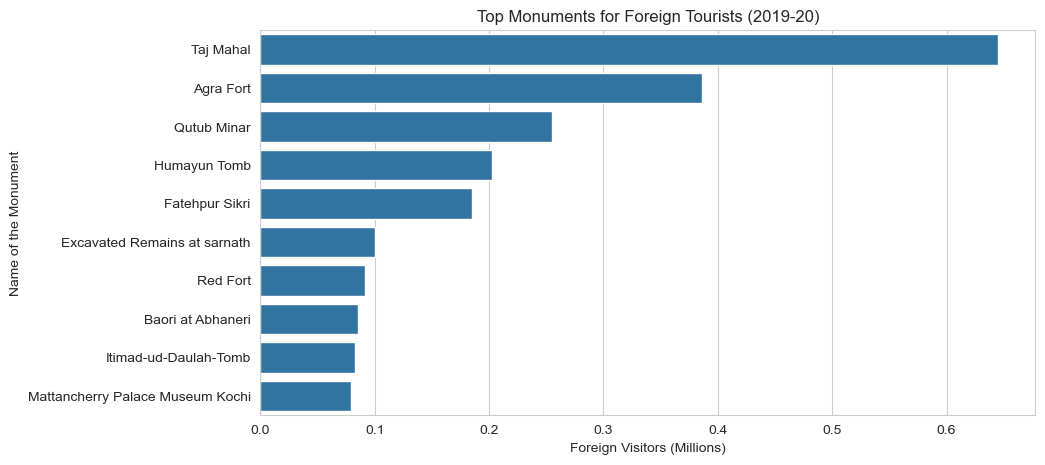

In [18]:
top_foreign = df.sort_values(by="Foreign-2019-20", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_foreign["Foreign-2019-20"] / 1_000_000,
    y=top_foreign["Name of the Monument"]
)

plt.xlabel("Foreign Visitors (Millions)")
plt.title("Top Monuments for Foreign Tourists (2019-20)")

plt.show()

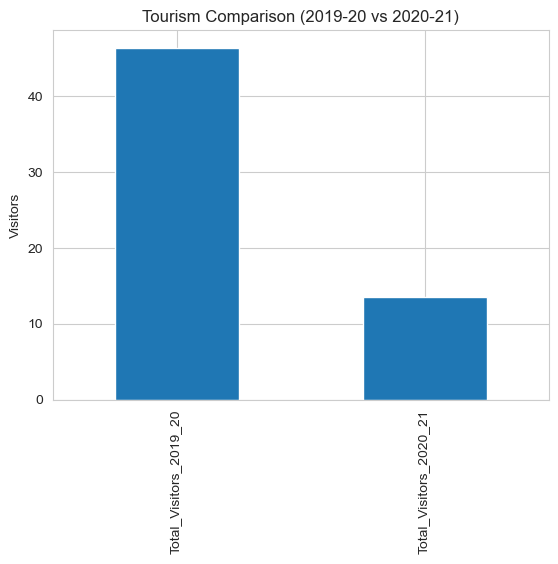

In [19]:
comparison = df[["Total_Visitors_2019_20", "Total_Visitors_2020_21"]].sum() /1_000_000

comparison.plot(kind="bar")
plt.title("Tourism Comparison (2019-20 vs 2020-21)")
plt.ylabel("Visitors")
plt.show()

In [24]:
df["Growth_%"] = ((df["Total_Visitors_2020_21"] - df["Total_Visitors_2019_20"]) / df["Total_Visitors_2019_20"]) * 100

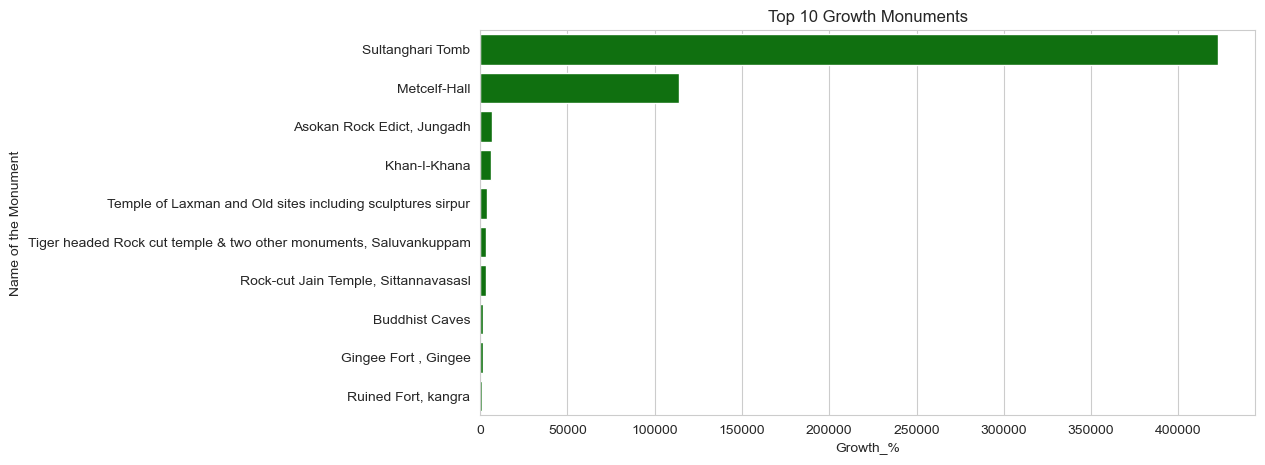

In [27]:

df_top = df.sort_values(by="Growth_%", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="Growth_%", y="Name of the Monument", data=df_top, color="green")

plt.title("Top 10 Growth Monuments")
plt.show()

In [29]:
def assign_zone(x):
    if x < 1_000_000:
        return "Low"
    elif x < 3_000_000:
        return "Medium"
    else:
        return "High"

df["Zone"] = df["Total_Visitors_2019_20"].apply(assign_zone)

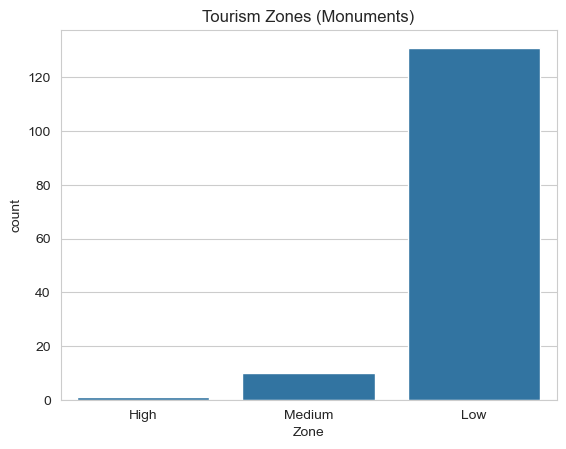

In [ ]:
sns.countplot(x="Zone", data=df) 
plt.title("Tourism Zones (Monuments)")
plt.show()

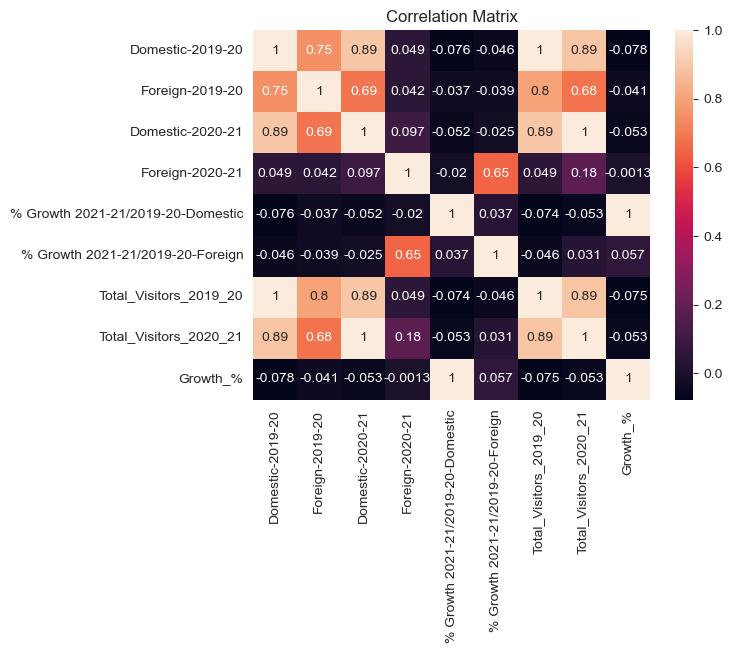

In [30]:
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [31]:
# Top 5 least affected monuments
df.sort_values(by="Growth_%", ascending=False).head(5)

,Circle,Name of the Monument,Domestic-2019-20,Foreign-2019-20,Domestic-2020-21,Foreign-2020-21,% Growth 2021-21/2019-20-Domestic,% Growth 2021-21/2019-20-Foreign,Total_Visitors_2019_20,Total_Visitors_2020_21,Growth_%,Zone
123,Delhi,Sultanghari Tomb,530,6,22969,233,4233.77,3783.33,536,23202,4228.731343,Low
78,Kolkata,Metcelf-Hall,605,27,7818,24,1192.23,-11.11,632,7842,1140.822785,Low
80,Rajkot,"Asokan Rock Edict, Jungadh",6176,168,10498,16,69.98,-90.48,6344,10514,65.731400,Low
122,Delhi,Khan-I-Khana,1782,45,3002,10,68.46,-77.78,1827,3012,64.860427,Low
162,Raipur,Temple of Laxman and Old sites including sculp...,63759,96,44742,44746,-29.83,46510.42,63855,89488,40.142510,Medium
